<a href="hhttps://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab2/L2_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2.3 Time and frequency domain calculations and analysis using ADXL345 data



For this section of Lab 2, have ready in hand all CSV files (highest rate outcome of 3200 Hz) from each activity: no fan, fan in normal condition, and  fan in anomalous condition.

For this portion of the lab, you will no longer need to use the Raspberry PI as you already have the data collected.

**You will run all your code using this Colab notebook**

## 3.1 Signal Processing and plotting data from: Fan off data

### Reading a CSV file and plotting data

In this part, we will read the saved CSV file generated in Lab 2.2 and then plot the data. A sample code structure is given below. It includes frequency domain transformations as well. However, the plotting part of the FFT signals is incomplete. You should finish the incomplete part.

Please note that you must change the ‘filename’ variable according to the CSV file you saved in the previous part. By modifying and adding lines, try to calculate time domain features from each axis data in Table 1 in the Prelab 2.2, such as mean, standard deviation, root mean square, and so on.






Import essential libraries:

In [2]:
import matplotlib
#matplotlib.use('tkagg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io
import seaborn as sns
import csv

The following code allows you to upload the data stored in a csv file to this Colab notebook.

In [4]:
#This code allows you to upload a file from your local drive
from google.colab import files
uploaded = files.upload()
#If you will work with excel, please save your file with a .CSV format
#Check the output file name below. You will use that file name in the next block.

Saving 20260716_140110_lab2_fan_normal.csv to 20260716_140110_lab2_fan_normal (1).csv
Saving 20260716_140709_lab2_fan_abnormal.csv to 20260716_140709_lab2_fan_abnormal (1).csv
Saving 20260716_141346_lab2_no_fan.csv to 20260716_141346_lab2_no_fan.csv


The next coding block extracts information from the csv file, and saves it through arrays.
The FFT fourier code is incomplete (a_y, and a_z are not coded). Please finish coding it and plot it by uncommenting the plot code lines.

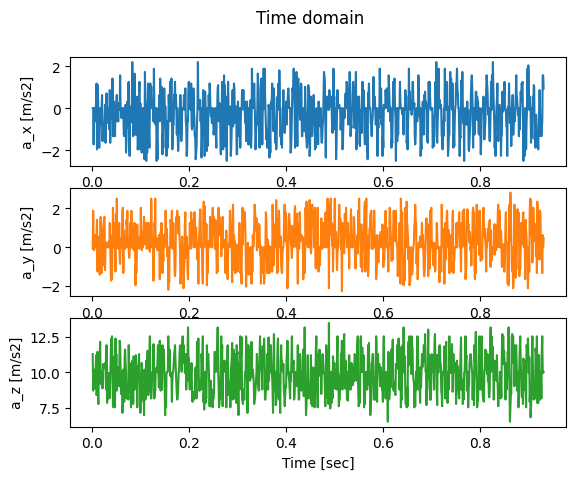

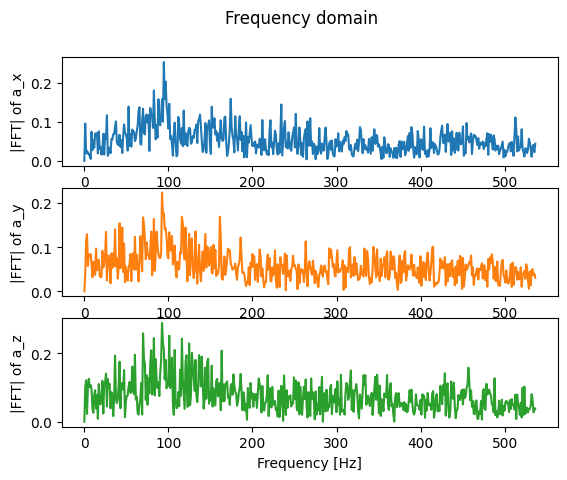

In [6]:
from pandas.core.internals.construction import dict_to_mgr

filename1 = '20260716_141346_lab2_no_fan.csv' #Insert the imported csv file name (copy the bolded text from the previous output) from the previous step inside the quotations
#Declaring arrays
dt = [] # sampling period list, dt
t = [] # time list, t
a_x = [] # x-axis acceleration list, a_x
a_y = [] # y-axis acceleration list, a_y
a_z = [] # z-axis acceleration list, a_z

# Reading a CSV file and convert rows as data

with open(filename1, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt.append(float(row[0]))
        t.append(float(row[1]))
        a_x.append(float(row[2]))
        a_y.append(float(row[3]))
        a_z.append(float(row[4]))

N = int(len(dt)) # Number of sample = 1000
T = t[-1]/N # sampling period, assumed equally distributed


n = np.array(range(len(dt))) + 1 # measured sequence
dt = np.array(dt) # convert dt list to dt 1D array
t = np.array(t) # convert t list to t 1D array
a_x = np.array(a_x) # convert a_x list to a_x 1D array
a_y = np.array(a_y) # convert a_y list to a_y 1D array
a_z = np.array(a_z) # convert a_z list to a_z 1D array


fig1, ax1 = plt.subplots(3)
fig1.suptitle('Time domain')
ax1[0].plot(t,a_x,'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t,a_y, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t,a_z, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')


from scipy.fft import fft, fftfreq

# get_fft is a function to calculate FFT
# arguments are x(signal array), T(sampling period), N(number of Samples)
# returns are f(frequency array) and y_mag(FFT magnitude array)
def get_fft(x, T, N):
    f = fftfreq(N, T)[:N//2]
    y_mag = 2/N * np.abs(fft(x)[:N//2])
    y_mag[0] = 0
    return f, y_mag


f_x, y_x = get_fft(a_x, T, N)
f_y, y_y = get_fft(a_y, T, N)
f_z, y_z = get_fft(a_z ,T ,N)

fig2, ax2 = plt.subplots(3)
fig2.suptitle('Frequency domain')
ax2[0].plot(f_x,y_x,'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y,y_y,'tab:orange')
ax2[1].set_ylabel('|FFT| of a_y')
ax2[2].plot(f_z,y_z,'tab:green')
ax2[2].set_ylabel('|FFT| of a_z')
ax2[2].set_xlabel('Frequency [Hz]')

plt.show()


## 3.2 Signal Processing and plotting data from: Fan normal condition data

Reuse the code above to process the data and plot the signal for fan data in normal conditions.

HINT: Do not use the same variables names from code above. You will need all data information stored in different variables for Section 3.4

In [10]:
#Insert the block of code to upload the csv file here:
#

filename2='20260716_140110_lab2_fan_normal.csv'
#Declaring arrays
dt_normal = [] # sampling period list, dt
t_normal = [] # time list, t
a_x_normal = [] # x-axis acceleration list, a_x
a_y_normal = [] # y-axis acceleration list, a_y
a_z_normal = [] # z-axis acceleration list, a_z

# Reading a CSV file and convert rows as data

with open(filename2, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt_normal.append(float(row[0]))
        t_normal.append(float(row[1]))
        a_x_normal.append(float(row[2]))
        a_y_normal.append(float(row[3]))
        a_z_normal.append(float(row[4]))


#

In [20]:
#Insert the block of code for calculating time-domain features:
#Print out all time domain features in this block
#
N_normal=len(dt_normal)
T_normal=t_normal[-1]/N_normal

n_normal = np.array(range(len(dt_normal))) + 1 # measured sequence
dt_normal = np.array(dt_normal) # convert dt_normal list to dt_normal 1D array
t_normal = np.array(t_normal) # convert t_normal list to t_normal 1D array
a_x_normal = np.array(a_x_normal) # convert a_x_normal list to a_x_normal 1D array
a_y_normal = np.array(a_y_normal) # convert a_y_normal list to a_y_normal 1D array
a_z_normal = np.array(a_z_normal) # convert a_z_normal list to a_z_normal1D array

# Time-domain feature calculation function
def get_time_features(data):
    N = len(data)

    mean_value = np.mean(data)
    std_value = np.std(data, ddof=1)
    rms_value = np.sqrt(np.mean(data**2))
    peak_value = np.max(np.abs(data))

    skewness_value = np.sum((data - mean_value)**3) / ((N - 1) * std_value**3)

    kurtosis_value = np.sum((data - mean_value)**4) / ((N - 1) * std_value**4)

    crest_factor_value = peak_value / rms_value

    return (
        mean_value,
        std_value,
        rms_value,
        peak_value,
        skewness_value,
        kurtosis_value,
        crest_factor_value
    )


# Calculate features for each axis
features_x_normal = get_time_features(a_x_normal)
features_y_normal = get_time_features(a_y_normal)
features_z_normal = get_time_features(a_z_normal)


# Print function
def print_time_features(axis_name, features):
    print(f"\nNormal fan - {axis_name}")
    print("Mean:", features[0])
    print("Standard deviation:", features[1])
    print("RMS:", features[2])
    print("Peak:", features[3])
    print("Skewness:", features[4])
    print("Kurtosis:", features[5])
    print("Crest factor:", features[6])


# Print all features
print_time_features("X-axis", features_x_normal)
print_time_features("Y-axis", features_y_normal)
print_time_features("Z-axis", features_z_normal)
#


Normal fan - X-axis
Mean: -0.16945891199999996
Standard deviation: 1.7397023760484325
RMS: 1.7470701519193663
Peak: 4.5502856
Skewness: 0.008482436059507948
Kurtosis: 2.4882159841132157
Crest factor: 2.604523690706389

Normal fan - Y-axis
Mean: 0.0543680676
Standard deviation: 1.5768404782064083
RMS: 1.576989332427795
Peak: 4.8640984
Skewness: 0.04872595614651557
Kurtosis: 2.6848443270380478
Crest factor: 3.0844206108304224

Normal fan - Z-axis
Mean: 10.028751009199999
Standard deviation: 1.7148660580891197
RMS: 10.174166876757965
Peak: 14.435388799999998
Skewness: -0.08491683533484722
Kurtosis: 2.5436785004717453
Crest factor: 1.41882760277664


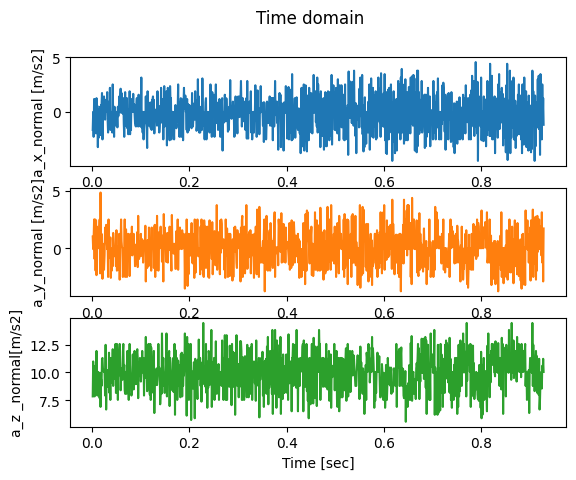

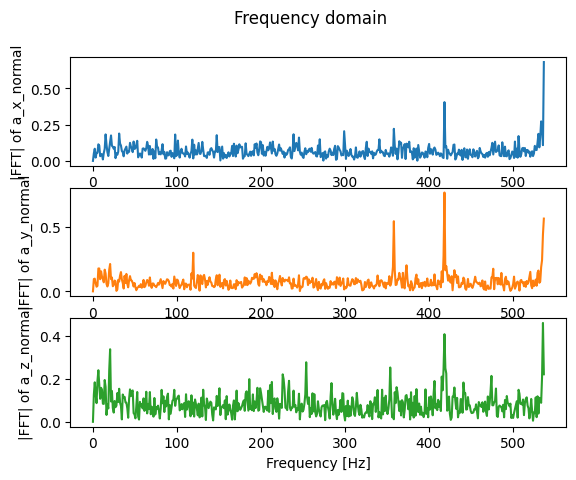

In [16]:
#Insert the block of code for processing and plotting here:
#



fig1_normal, ax1_normal = plt.subplots(3)
fig1_normal.suptitle('Time domain')
ax1_normal[0].plot(t_normal,a_x_normal,'tab:blue')
ax1_normal[0].set_ylabel('a_x_normal [m/s2]')
ax1_normal[1].plot(t_normal,a_y_normal, 'tab:orange')
ax1_normal[1].set_ylabel('a_y_normal [m/s2]')
ax1_normal[2].plot(t_normal,a_z_normal, 'tab:green')
ax1_normal[2].set_ylabel('a_z_normal[m/s2]')
ax1_normal[2].set_xlabel('Time [sec]')


from scipy.fft import fft, fftfreq

f_x_normal, y_x_normal = get_fft(a_x_normal, T_normal, N_normal)
f_y_normal, y_y_normal = get_fft(a_y_normal, T_normal, N_normal)
f_z_normal, y_z_normal = get_fft(a_z_normal ,T_normal ,N_normal)

fig2_normal, ax2_normal = plt.subplots(3)
fig2_normal.suptitle('Frequency domain')
ax2_normal[0].plot(f_x_normal,y_x_normal,'tab:blue')
ax2_normal[0].set_ylabel('|FFT| of a_x_normal')
ax2_normal[1].plot(f_y_normal,y_y_normal,'tab:orange')
ax2_normal[1].set_ylabel('|FFT| of a_y_normal')
ax2_normal[2].plot(f_z_normal,y_z_normal,'tab:green')
ax2_normal[2].set_ylabel('|FFT| of a_z_normal')
ax2_normal[2].set_xlabel('Frequency [Hz]')

plt.show()

#

## 3.3 Signal Processing and plotting data from: Fan anomalous condition data

Reuse the code above to process the data and plot the signal for fan data in normal conditions.

HINT: Do not use the same variables names from code above. You will need all data information stored in different variables for Section 3.4

In [17]:
#Insert the block of code to upload the csv file here:
#


filename3='20260716_140709_lab2_fan_abnormal.csv'
#Declaring arrays
dt_abnormal = [] # sampling period list, dt
t_abnormal = [] # time list, t
a_x_abnormal = [] # x-axis acceleration list, a_x
a_y_abnormal = [] # y-axis acceleration list, a_y
a_z_abnormal = [] # z-axis acceleration list, a_z

# Reading a CSV file and convert rows as data

with open(filename3, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt_abnormal.append(float(row[0]))
        t_abnormal.append(float(row[1]))
        a_x_abnormal.append(float(row[2]))
        a_y_abnormal.append(float(row[3]))
        a_z_abnormal.append(float(row[4]))


#

In [21]:
#Insert the block of code for calculating time-domain features:
#Print out all time domain features in this block
#
N_abnormal=len(dt_abnormal)
T_abnormal=t_abnormal[-1]/N_abnormal

n_abnormal = np.array(range(len(dt_abnormal))) + 1 # measured sequence
dt_abnormal = np.array(dt_abnormal) # convert dt_abnormal list to dt_abnormal 1D array
t_abnormal = np.array(t_abnormal) # convert t_abnormal list to t_normal 1D array
a_x_abnormal = np.array(a_x_abnormal) # convert a_x_abnormal list to a_x_abnormal 1D array
a_y_abnormal = np.array(a_y_abnormal) # convert a_y_abnormal list to a_y_abnormal 1D array
a_z_abnormal = np.array(a_z_abnormal) # convert a_z_abnormal list to a_z_abnormal1D array

# Calculate features for each axis
features_x_abnormal = get_time_features(a_x_abnormal)
features_y_abnormal = get_time_features(a_y_abnormal)
features_z_abnormal = get_time_features(a_z_abnormal)

print_time_features("X-axis", features_x_abnormal)
print_time_features("Y-axis", features_y_abnormal)
print_time_features("Z-axis", features_z_abnormal)
#


Normal fan - X-axis
Mean: -0.24987344199999995
Standard deviation: 3.595020275081797
RMS: 3.601899963142768
Peak: 20.0840192
Skewness: -0.356012347340616
Kurtosis: 9.623277440760864
Crest factor: 5.575951416062115

Normal fan - Y-axis
Mean: 0.1475704692
Standard deviation: 1.7998113737738692
RMS: 1.8049539339175735
Peak: 10.3558224
Skewness: -0.35532865626734794
Kurtosis: 4.931602458411049
Crest factor: 5.737444155997455

Normal fan - Z-axis
Mean: 9.9566132918
Standard deviation: 2.553627437188646
RMS: 10.278552442699464
Peak: 20.0447926
Skewness: 0.14375587337883386
Kurtosis: 4.938493408837673
Crest factor: 1.95015715605335


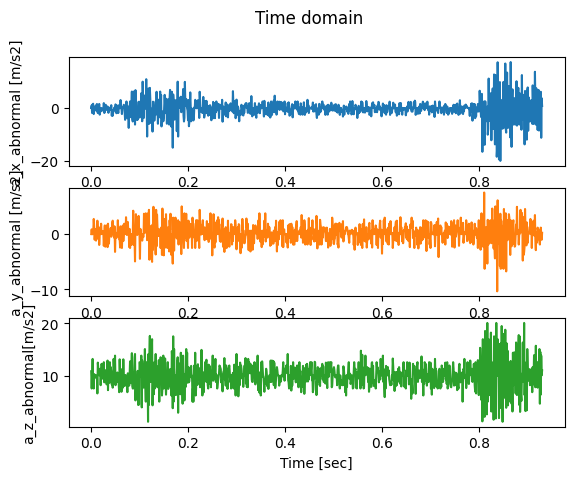

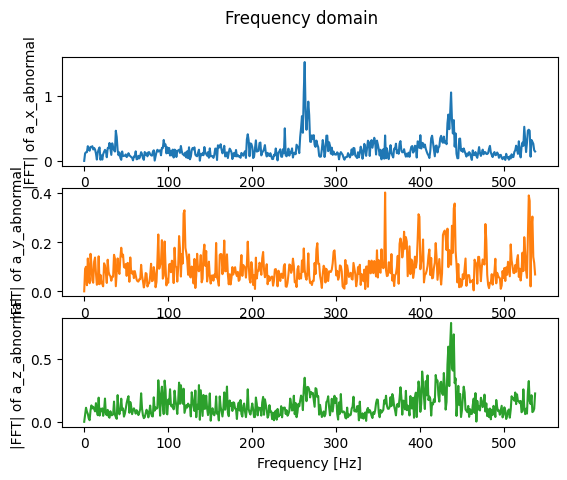

In [19]:
#Insert the block of code for processing and plotting here:
#


fig1_abnormal, ax1_abnormal = plt.subplots(3)
fig1_abnormal.suptitle('Time domain')
ax1_abnormal[0].plot(t_abnormal,a_x_abnormal,'tab:blue')
ax1_abnormal[0].set_ylabel('a_x_abnormal [m/s2]')
ax1_abnormal[1].plot(t_abnormal,a_y_abnormal, 'tab:orange')
ax1_abnormal[1].set_ylabel('a_y_abnormal [m/s2]')
ax1_abnormal[2].plot(t_abnormal,a_z_abnormal, 'tab:green')
ax1_abnormal[2].set_ylabel('a_z_abnormal[m/s2]')
ax1_abnormal[2].set_xlabel('Time [sec]')


from scipy.fft import fft, fftfreq

f_x_abnormal, y_x_abnormal = get_fft(a_x_abnormal, T_abnormal, N_abnormal)
f_y_abnormal, y_y_abnormal = get_fft(a_y_abnormal, T_abnormal, N_abnormal)
f_z_abnormal, y_z_abnormal = get_fft(a_z_abnormal ,T_abnormal ,N_abnormal)

fig2_abnormal, ax2_abnormal = plt.subplots(3)
fig2_abnormal.suptitle('Frequency domain')
ax2_abnormal[0].plot(f_x_abnormal,y_x_abnormal,'tab:blue')
ax2_abnormal[0].set_ylabel('|FFT| of a_x_abnormal')
ax2_abnormal[1].plot(f_y_abnormal,y_y_abnormal,'tab:orange')
ax2_abnormal[1].set_ylabel('|FFT| of a_y_abnormal')
ax2_abnormal[2].plot(f_z_abnormal,y_z_abnormal,'tab:green')
ax2_abnormal[2].set_ylabel('|FFT| of a_z_abnormal')
ax2_abnormal[2].set_xlabel('Frequency [Hz]')

plt.show()


#

## 3.4 Contrasting time and frequency domain plots between datasets: Normal vs Anomalous

#### TASK 3.4

You will use the data you have worked through this Colab notebook. No need to re-run all codes.
1.	Make a comparative figure between the time-domain graphs on normal and anomalous data.

       * Column 1: Normal data, Column 2: Anomalous data

       * Row 1: a_x, Row 2: a_y, Row 3: a_z

2. Repeat 1. Make a comparative figure between the frequency-domain graphs on normal and anomalous data.
2.	Add your name at the end of the tile of each plot (e.g., ‘Time domain, John Doe’)


Text(0.5, 0, 'Frequency [Hz]')

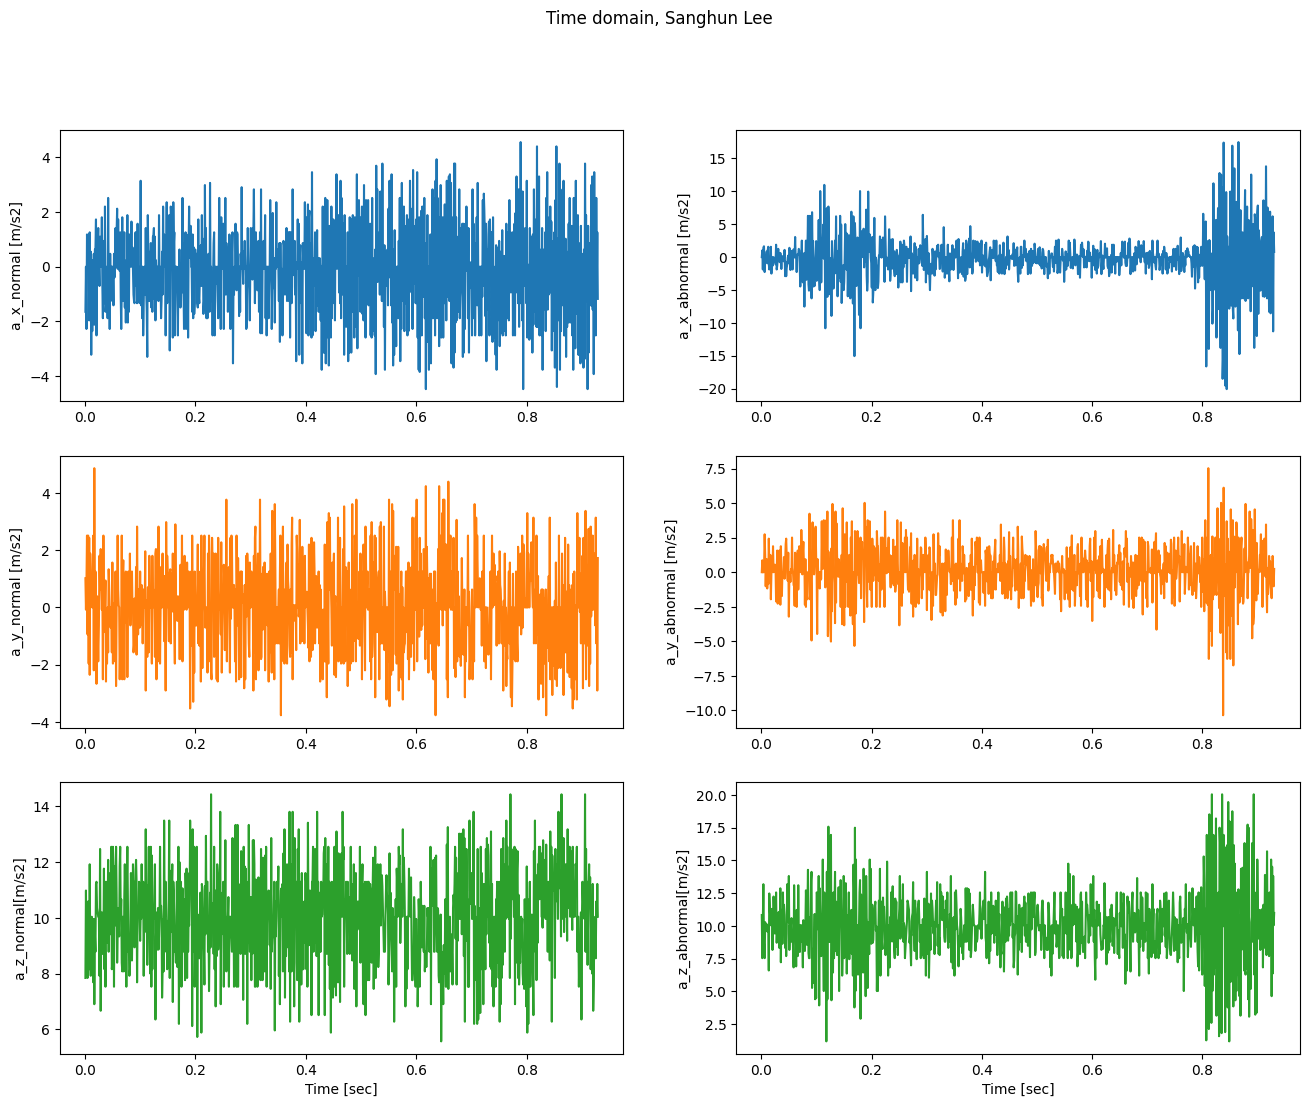

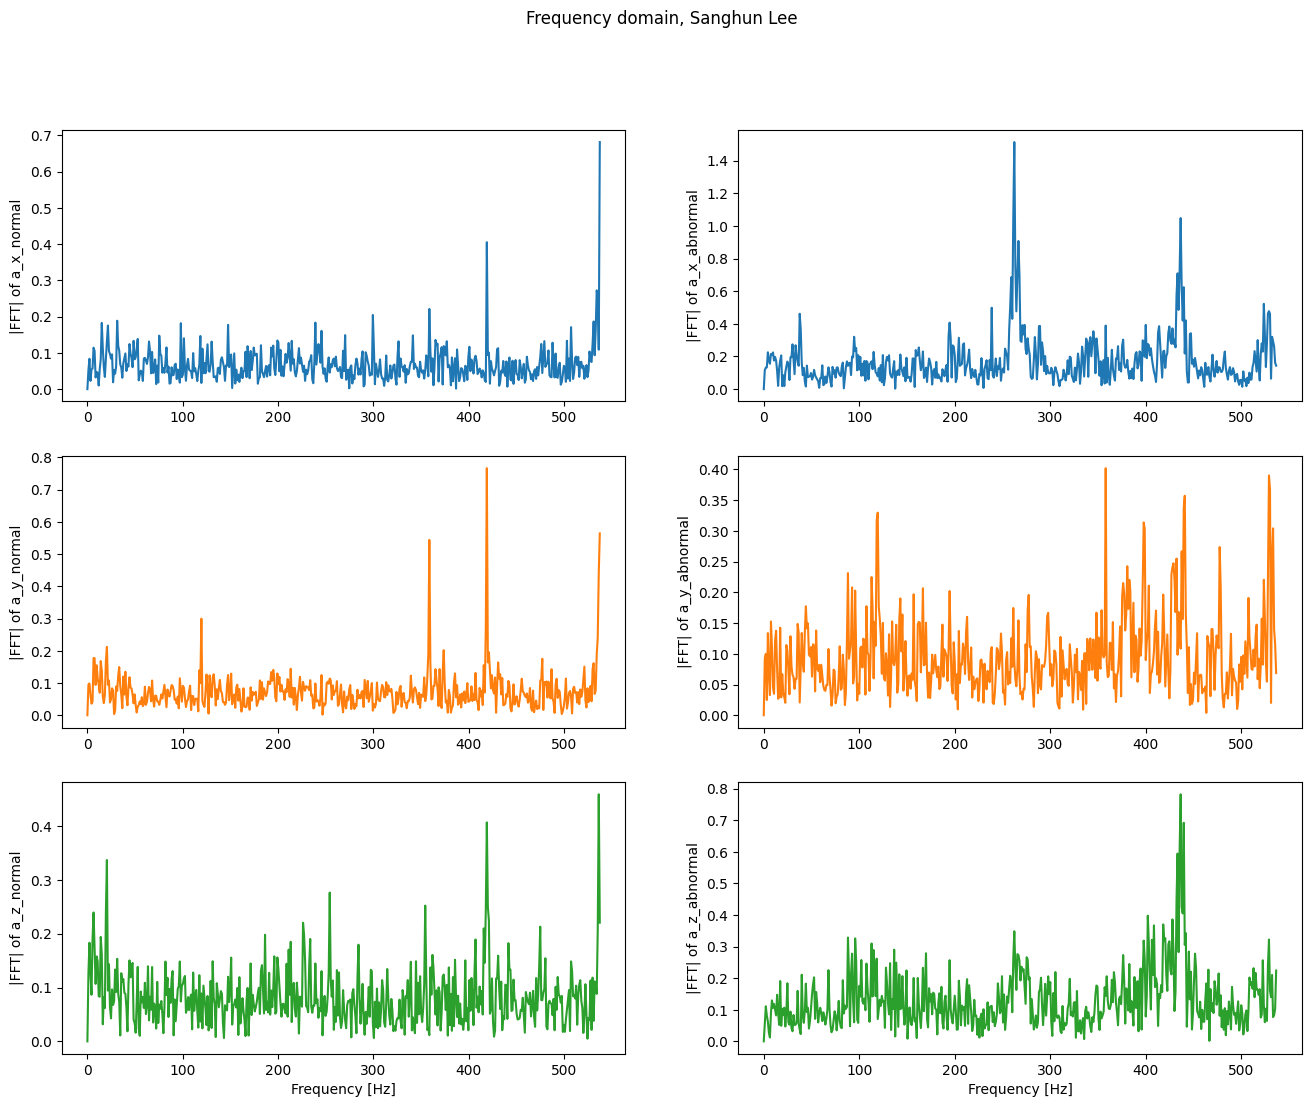

In [28]:
#Insert your code here:
#Provide comments to describe your code
#

fig3, ax3 = plt.subplots(3,2,figsize=(16, 12))
fig3.suptitle('Time domain, Sanghun Lee')
ax3[0,0].plot(t_normal,a_x_normal,'tab:blue')
ax3[0,0].set_ylabel('a_x_normal [m/s2]')
ax3[1,0].plot(t_normal,a_y_normal, 'tab:orange')
ax3[1,0].set_ylabel('a_y_normal [m/s2]')
ax3[2,0].plot(t_normal,a_z_normal, 'tab:green')
ax3[2,0].set_ylabel('a_z_normal[m/s2]')
ax3[2,0].set_xlabel('Time [sec]')


ax3[0,1].plot(t_abnormal,a_x_abnormal,'tab:blue')
ax3[0,1].set_ylabel('a_x_abnormal [m/s2]')
ax3[1,1].plot(t_abnormal,a_y_abnormal, 'tab:orange')
ax3[1,1].set_ylabel('a_y_abnormal [m/s2]')
ax3[2,1].plot(t_abnormal,a_z_abnormal, 'tab:green')
ax3[2,1].set_ylabel('a_z_abnormal[m/s2]')
ax3[2,1].set_xlabel('Time [sec]')


fig4, ax4 = plt.subplots(3,2,figsize=(16, 12))

fig4.suptitle('Frequency domain, Sanghun Lee')
ax4[0,0].plot(f_x_normal,y_x_normal,'tab:blue')
ax4[0,0].set_ylabel('|FFT| of a_x_normal')
ax4[1,0].plot(f_y_normal,y_y_normal,'tab:orange')
ax4[1,0].set_ylabel('|FFT| of a_y_normal')
ax4[2,0].plot(f_z_normal,y_z_normal,'tab:green')
ax4[2,0].set_ylabel('|FFT| of a_z_normal')
ax4[2,0].set_xlabel('Frequency [Hz]')


ax4[0,1].plot(f_x_abnormal,y_x_abnormal,'tab:blue')
ax4[0,1].set_ylabel('|FFT| of a_x_abnormal')
ax4[1,1].plot(f_y_abnormal,y_y_abnormal,'tab:orange')
ax4[1,1].set_ylabel('|FFT| of a_y_abnormal')
ax4[2,1].plot(f_z_abnormal,y_z_abnormal,'tab:green')
ax4[2,1].set_ylabel('|FFT| of a_z_abnormal')
ax4[2,1].set_xlabel('Frequency [Hz]')

#


### Compare data of two conditions (normal vs. anomalous) of the axial flow fan.
  



#### 1) What contrast could be made between comparing time-domain characteristics of normal vs anomalous condition data?
---

Normal data shows relatively stable vibration with smaller amplitude and more consistent signal patterns. In contrast, anomalous data exhibits larger vibration amplitudes, sudden spikes, and greater fluctuations, especially near the end of the measurement. These characteristics indicate increased vibration and instability under the anomalous condition.

---

#### 2) What are the main frequencies and FFT magnitudes of each measurement?
---

In the normal condition, the dominant frequencies were approximately 537.29 Hz (a_x), 418.85 Hz (a_y), and 536.21 Hz (a_z) with FFT magnitudes of 0.6812, 0.7662, and 0.4590, respectively. Under the abnormal condition, the dominant frequencies shifted to 262.33 Hz, 358.01 Hz, and 436.50 Hz, and the FFT magnitudes changed significantly. In particular, the a_x axis showed the largest increase in FFT magnitude from 0.6812 to 1.5139, indicating much stronger vibration under the abnormal condition.

---

In [29]:
# Normal condition
idx_x_normal = np.argmax(y_x_normal)
idx_y_normal = np.argmax(y_y_normal)
idx_z_normal = np.argmax(y_z_normal)

main_freq_x_normal = f_x_normal[idx_x_normal]
main_mag_x_normal = y_x_normal[idx_x_normal]

main_freq_y_normal = f_y_normal[idx_y_normal]
main_mag_y_normal = y_y_normal[idx_y_normal]

main_freq_z_normal = f_z_normal[idx_z_normal]
main_mag_z_normal = y_z_normal[idx_z_normal]


# Abnormal condition
idx_x_abnormal = np.argmax(y_x_abnormal)
idx_y_abnormal = np.argmax(y_y_abnormal)
idx_z_abnormal = np.argmax(y_z_abnormal)

main_freq_x_abnormal = f_x_abnormal[idx_x_abnormal]
main_mag_x_abnormal = y_x_abnormal[idx_x_abnormal]

main_freq_y_abnormal = f_y_abnormal[idx_y_abnormal]
main_mag_y_abnormal = y_y_abnormal[idx_y_abnormal]

main_freq_z_abnormal = f_z_abnormal[idx_z_abnormal]
main_mag_z_abnormal = y_z_abnormal[idx_z_abnormal]


# Print results
print("Normal condition")
print("a_x: Main frequency =", main_freq_x_normal,
      "Hz, FFT magnitude =", main_mag_x_normal)

print("a_y: Main frequency =", main_freq_y_normal,
      "Hz, FFT magnitude =", main_mag_y_normal)

print("a_z: Main frequency =", main_freq_z_normal,
      "Hz, FFT magnitude =", main_mag_z_normal)


print("\nAbnormal condition")
print("a_x: Main frequency =", main_freq_x_abnormal,
      "Hz, FFT magnitude =", main_mag_x_abnormal)

print("a_y: Main frequency =", main_freq_y_abnormal,
      "Hz, FFT magnitude =", main_mag_y_abnormal)

print("a_z: Main frequency =", main_freq_z_abnormal,
      "Hz, FFT magnitude =", main_mag_z_abnormal)

Normal condition
a_x: Main frequency = 537.2872008311306 Hz, FFT magnitude = 0.6811576678922463
a_y: Main frequency = 418.8471365196589 Hz, FFT magnitude = 0.766187219693483
a_z: Main frequency = 536.2104729737536 Hz, FFT magnitude = 0.45895228776391017

Abnormal condition
a_x: Main frequency = 262.32777727224374 Hz, FFT magnitude = 1.5138728868610924
a_y: Main frequency = 358.01290914613594 Hz, FFT magnitude = 0.4018423827219574
a_z: Main frequency = 436.4962195595531 Hz, FFT magnitude = 0.782192239058742


#### 3) Which domain features are better to detect the abnormal condition of the fan? Explain why.
---

Frequency-domain features are better for detecting the abnormal condition of the fan. FFT clearly identifies the dominant vibration frequencies and their magnitudes. In the abnormal condition, the dominant frequencies shifted and the FFT magnitude, especially on the a_x axis, increased significantly (from 0.681 to 1.514). These changes are easier to distinguish than the time-domain signals, which mainly show larger fluctuations but do not clearly reveal the vibration frequency components. Therefore, frequency-domain features provide a more reliable indication of abnormal fan operation.

---

#### 4) From the three measured dimensions, Which dimension shows the best salient feature in order to detect vibration? Explain why.
---

The a_x dimension shows the most salient feature for detecting vibration. In the abnormal condition, the main FFT magnitude of a_x increased significantly from approximately 0.681 to 1.514, which is the largest change among the three axes. The time-domain signal of a_x also showed larger fluctuations and stronger vibration amplitudes under the abnormal condition. Therefore, the x-axis provides the clearest distinction between normal and abnormal fan operation.

---

## Lab2 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab2.

---

In Lab 2, we learned how to acquire, store, process, and visualize acceleration data using a Raspberry Pi and an accelerometer sensor. First, the sensor output data rate was configured, and acceleration data from the x, y, and z axes were collected and saved as CSV files.

The saved CSV data were then imported into Python and converted into NumPy arrays. The actual sampling period and sampling frequency were calculated from the recorded time data. Time-domain features, including mean, standard deviation, RMS, peak, skewness, kurtosis, and crest factor, were calculated for each acceleration axis.

FFT was also applied to convert the acceleration signals from the time domain to the frequency domain. The dominant frequencies and their FFT magnitudes were identified for both normal and abnormal fan conditions. Comparative time-domain and frequency-domain plots were created for the three axes.

The abnormal fan generally showed larger vibration amplitudes and different dominant frequency components than the normal fan. In particular, the x-axis showed the clearest difference, with the main FFT magnitude increasing from approximately 0.681 in the normal condition to 1.514 in the abnormal condition. Therefore, the x-axis and frequency-domain features were the most useful for detecting the abnormal fan condition.

---


### Q2. What skills did you have to develop to accomplish this project?

---

To accomplish this project, I had to develop skills in sensor interfacing, data acquisition, and Python-based signal processing. I learned how to configure an accelerometer connected to a Raspberry Pi, collect three-axis vibration data, and save the measurements in CSV format. I also improved my ability to use NumPy, SciPy, and Matplotlib to calculate time-domain features, perform FFT analysis, and visualize normal and abnormal fan conditions.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---
The most beneficial aspect of this project was connecting the complete process from sensor measurement to data analysis. I learned how acceleration data are collected from a real sensor, stored in a CSV file, and processed using Python. Comparing normal and abnormal fan data in both the time and frequency domains was especially useful because it showed how statistical features and FFT results can be used to identify abnormal vibration.

---

### Q4. What challenges did you encounter in completing the project?

---

One of the main challenges was understanding and interpreting the FFT transformation code. It was difficult to understand how the time-domain acceleration data were converted into frequency-domain data and how the frequency and magnitude arrays were generated. I also had to understand why only half of the FFT result was used, how the magnitude was normalized, and how the dominant frequency was identified.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

I overcame these challenges by reviewing the FFT code line by line and studying the role of each function.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)